# 07 A first dynamics run

*CORE*

**Question:** How does one machine swing after a fault?

- Declare a classical single-machine-infinite-bus model and a 3-phase fault cleared at 1.06 s.
- Solve the transient with OpenDSS and inspect rotor angle swing and stability checks.
- Machine values are illustrative teaching data, not a citation and not a stability study of any real plant.


## ⚙ Setup — Initialize the teaching environment

Run the setup cell once to load helpers and check runtime dependencies.


In [1]:
#@title 1. Setup — run once
from hashlib import sha256
from urllib.request import urlopen

_bootstrap_url = "https://raw.githubusercontent.com/sarutesri/cept-studio-edu/main/public/notebooks/_lesson.py"
_bootstrap = urlopen(_bootstrap_url, timeout=60).read()
if sha256(_bootstrap).hexdigest() != "7707385fd5fe60a9bec2e0bdd1bda33bc7b06bab71a8304dff0a7de86d23a0c6":
    raise ValueError("Lesson helper hash mismatch")
exec(compile(_bootstrap, "cept-lesson", "exec"), globals())


CEPT_WHEEL_URL not supplied; using the existing installed environment.
CLI: cept --version


cept-power-studio 0.2.0.dev0


Lesson helpers ready. Stage cells below run the same CEPT commands as a normal terminal.


## 🧩 Inputs — Declare the machine and disturbance

Declare a classical single-machine infinite-bus model with illustrative machine values and a cleared three-phase fault.


In [2]:
#@title 2. Inputs — machine parameters and disturbance
import json

CASE_DIR = WORKSPACE / "cases"
CASE_DIR.mkdir(parents=True, exist_ok=True)
CASE_PATH = CASE_DIR / "kundur_smib_classical_case.json"
RUN_DIR = WORKSPACE / "runs" / "first-dynamics"

# Machine parameters (H=3.5, D=0, Xd'=0.300001) are illustrative teaching values, not a citation.
CASE_PAYLOAD = {
  "meta": {
    "name": "kundur_smib_classical_case",
    "description": "Classical single-mass synchronous generator behind an infinite bus, driven through OpenDSS's native single-mass machine model. The network, operating point and disturbance follow Kundur, Power System Stability and Control (McGraw-Hill, 1994), Example 13.1: a 345/24 kV three-bus system, a 2220 MVA machine, Xt=0.15 pu, two parallel lines at 0.5 and 0.93 pu, an infinite bus at 0.90081 pu, and a 3-phase bolted fault on bus HT at t=1.0 s cleared at t=1.06 s by clearing the fault and opening Source_HT_2. H=3.5 MWs/MVA, D=0 and Xd'=0.3 pu are cited textbook values from that example; the line reactances are the book's pu values written in ohms on the machine base (Zb=345^2/2220=53.61 ohm, so 26.8075 ohm/km and 49.86195 ohm/km are 0.5 and 0.93 pu). These are teaching values drawn from a named textbook example rather than a citation of a machine data set: the numbers are the book's reduced classical values, and no full-order machine data set is claimed or recorded in this repository. The record carries slightly separated values (xd=xq=0.300002, xdp=xqp=0.300001, xdpp=xqpp=0.3, td0p=tq0p=0.001 s, td0pp=tq0pp=1e-6 s) so the classical study behaves as a reduced machine under a GENROU-shaped record; those separations and time constants are DERIVED NUMERICAL VALUES, not source data, and are not attributed to the book. The remaining GenrouDynamics fields are required by the Case schema and are NOT used by this reduced lane; they are filler for compatibility and carry no engineering meaning here. reference_xstr is the internal-emf reference the reduced machine is pinned to and is DERIVED from this Case's own Xd', which equals the textbook value. Two assumptions are inherited from the network and are reported as missing rather than filled in: the thermal rating of both lines. This Case demonstrates the workflow: a solver-backed run whose receipt checks convergence, monitor coverage over the whole declared window, finite channel values and a rotor-angle channel. It is WORKFLOW_VALIDATED only. It is not agreement with any reference, not a grid-code requirement, and not a measurement of a real machine or a project.",
    "author": "CEPT",
    "language": "en",
    "mode": "demonstrator"
  },
  "network": {
    "kind": "inline",
    "frequency_hz": 60,
    "source": {
      "kind": "grid"
    },
    "inline": {
      "buses": [
        {
          "name": "SourceBus",
          "kv": 345.0,
          "phases": 3
        },
        {
          "name": "HT",
          "kv": 345.0,
          "phases": 3
        },
        {
          "name": "LT",
          "kv": 24.0,
          "phases": 3
        }
      ],
      "lines": [
        {
          "name": "Source_HT_1",
          "from_bus": "SourceBus",
          "to_bus": "HT",
          "length_km": 1.0,
          "r1_ohm_per_km": 0.0,
          "x1_ohm_per_km": 26.8075,
          "b1_us_per_km": 0.0
        },
        {
          "name": "Source_HT_2",
          "from_bus": "SourceBus",
          "to_bus": "HT",
          "length_km": 1.0,
          "r1_ohm_per_km": 0.0,
          "x1_ohm_per_km": 49.86195,
          "b1_us_per_km": 0.0
        }
      ],
      "transformers": [
        {
          "name": "Step_Up",
          "hv_bus": "HT",
          "lv_bus": "LT",
          "mva": 2220.0,
          "hv_kv": 345.0,
          "lv_kv": 24.0,
          "uk_pct": 15.0,
          "x_r_ratio": 1000.0,
          "vector_group": "Dyn11"
        }
      ],
      "loads": [],
      "external_grids": [
        {
          "name": "SourceBus_Grid",
          "bus": "SourceBus",
          "pu": 0.90081,
          "angle_deg": 0.0,
          "sk3_mva": 100000000.0,
          "x_r_ratio": 10.0
        }
      ],
      "generators": [
        {
          "name": "G1",
          "bus": "LT",
          "bus_type": "pq",
          "mva": 2220.0,
          "kv": 24.0,
          "pu": 1.0,
          "kw": 1998000.0,
          "pf": 0.899957,
          "xdpp_pu": 0.3,
          "dynamics": {
            "h": 3.5,
            "d": 0.0,
            "xd": 0.300002,
            "xq": 0.300002,
            "xdp": 0.300001,
            "xqp": 0.300001,
            "xdpp": 0.3,
            "xqpp": 0.3,
            "xl": 0.3,
            "td0p": 0.001,
            "tq0p": 0.001,
            "ra": 0.0,
            "td0pp": 1e-06,
            "tq0pp": 1e-06,
            "reference_xstr": 0.300001
          }
        }
      ]
    }
  },
  "study": {
    "type": "dynamics",
    "options": {
      "dynamic_model": "gencls-classical"
    }
  },
  "dynamics": {
    "stepsize": 0.001,
    "duration": 5.0,
    "events": [
      {
        "t": 1.0,
        "kind": "fault",
        "target": "HT",
        "params": {
          "r": 0.0
        },
        "label": "3ph bolted fault on HT"
      },
      {
        "t": 1.06,
        "kind": "clear_fault",
        "target": "HT",
        "label": "clear fault"
      },
      {
        "t": 1.06,
        "kind": "open",
        "target": "Source_HT_2",
        "label": "trip faulted circuit"
      }
    ]
  },
  "standards": {
    "v_min_pu": 0.5,
    "v_max_pu": 1.15,
    "voltage_method": "range"
  }
}

CASE_PATH.write_text(json.dumps(CASE_PAYLOAD, indent=2) + "\n", encoding="utf-8")

table(
    ["declared input", "value", "unit", "basis"],
    [
        ("machine rating", 2220.0, "MVA", "teaching network"),
        ("rated voltage", 24.0, "kV", "teaching network"),
        ("inertia constant H", 3.5, "MWs/MVA", "illustrative teaching value"),
        ("damping coefficient D", 0.0, "pu", "illustrative teaching value"),
        ("transient reactance Xd'", 0.300001, "pu", "illustrative teaching value"),
        ("infinite bus voltage", 0.90081, "pu", "operating point"),
        ("fault location", "HT (345 kV bus)", "bus", "bolted 3-phase fault"),
        ("fault applied", 1.00, "s", "disturbance start"),
        ("fault cleared", 1.06, "s", "clearing time (60 ms)"),
        ("line trip", "Source_HT_2", "line", "tripped at 1.06 s"),
        ("simulation duration", 5.0, "s", "time step 1 ms"),
    ],
)


declared input           value            unit     basis
-----------------------  ---------------  -------  ---------------------------
machine rating           2220.0           MVA      teaching network
rated voltage            24.0             kV       teaching network
inertia constant H       3.5              MWs/MVA  illustrative teaching value
damping coefficient D    0.0              pu       illustrative teaching value
transient reactance Xd'  0.300001         pu       illustrative teaching value
infinite bus voltage     0.90081          pu       operating point
fault location           HT (345 kV bus)  bus      bolted 3-phase fault
fault applied            1.0              s        disturbance start
fault cleared            1.06             s        clearing time (60 ms)
line trip                Source_HT_2      line     tripped at 1.06 s
simulation duration      5.0              s        time step 1 ms


## ▶ Run — Solve the dynamic transient

Run `cept run cases/kundur_smib_classical_case.json`; CEPT integrates the electromechanical swing through OpenDSS.


In [3]:
# 3. Run study — same CEPT CLI as a normal terminal
!cept run cases/kundur_smib_classical_case.json \
    --out runs/first-dynamics \
    --force \
    --format text


CEPT study result: FINISHED
----------------------------
Result             Finished the study and saved the evidence
Saved run          runs\first-dynamics
Case fingerprint   71284d77dfb7 (matches the case you ran)

What this means
  The study completed and saved solver-backed evidence.
  It does NOT approve a real project or field installation.

Next
  cept verify runs\first-dynamics --format text


## 📊 Results — Inspect the transient swing

Read the decisive transient quantities from `results.json`: peak rotor angle, frequency limits, and stability verdict.


In [4]:
#@title 4. Engineering result — rotor swing and stability
RUN_DIR = WORKSPACE / "runs" / "first-dynamics"
results = read(RUN_DIR / "results.json")
dynamics = results["dynamics"]

st_monitor = next(m for m in dynamics["monitors"] if m["name"] == "cept_g1_st")
speed_channel = next(c for c in st_monitor["channels"] if c["name"] == "Speed")
final_speed_pu = speed_channel["values"][-1]
final_speed_dev = final_speed_pu - 1.0

table(
    ["quantity", "value", "unit", "solver verdict / meaning"],
    [
        ("simulation convergence", dynamics["converged"], "bool", "OpenDSS converged"),
        ("transient stability", dynamics["stable"], "bool", dynamics["settling_note"]),
        ("maximum rotor angle", dynamics["max_rotor_angle_deg"], "deg", "bounded swing (<180 deg)"),
        ("frequency nadir", dynamics["freq_nadir_hz"], "Hz", "minimum frequency during swing"),
        ("frequency peak", dynamics["freq_peak_hz"], "Hz", "maximum frequency during swing"),
        ("final speed deviation", f"{final_speed_dev:+.5f}", "pu", "deviation from 1.0 pu synchronous speed"),
        ("simulation duration", dynamics["duration"], "s", "integrated time window"),
        ("integration step", dynamics["stepsize"], "s", "fixed time step (1 ms)"),
    ],
)

assert dynamics["converged"] is True
assert dynamics["stable"] is True
assert dynamics["duration"] == 5.0
assert dynamics["stepsize"] == 0.001
assert round(float(dynamics["max_rotor_angle_deg"]), 3) == 120.615
assert round(float(dynamics["freq_nadir_hz"]), 4) == 59.5188
assert round(float(dynamics["freq_peak_hz"]), 4) == 60.4812
assert abs(final_speed_pu - 1.00023) < 1e-4
assert "transiently stable" in dynamics["settling_note"]


quantity                value     unit  solver verdict / meaning
----------------------  --------  ----  ----------------------------------------------------
simulation convergence  True      bool  OpenDSS converged
transient stability     True      bool  Rotor angle bounded (<180 deg) — transiently stable.
maximum rotor angle     120.615   deg   bounded swing (<180 deg)
frequency nadir         59.5188   Hz    minimum frequency during swing
frequency peak          60.4812   Hz    maximum frequency during swing
final speed deviation   +0.00023  pu    deviation from 1.0 pu synchronous speed
simulation duration     5.0       s     integrated time window
integration step        0.001     s     fixed time step (1 ms)


## 📈 Plot — Rotor angle and speed traces

Read the recorded monitor traces from `results.json` and plot the rotor angle and speed versus time.


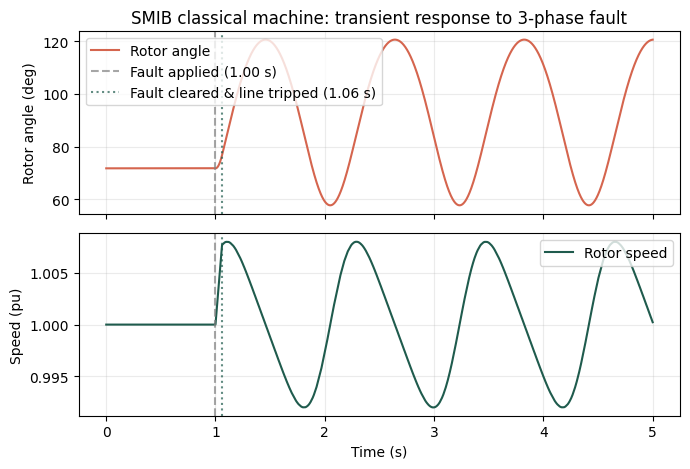

In [5]:
#@title 5. Plot — rotor angle and speed vs time
import matplotlib.pyplot as plt
from IPython.display import display

RUN_DIR = WORKSPACE / "runs" / "first-dynamics"
results = read(RUN_DIR / "results.json")
dynamics = results["dynamics"]

st_monitor = next(m for m in dynamics["monitors"] if m["name"] == "cept_g1_st")
t_s = st_monitor["t"]
angle_deg = next(c["values"] for c in st_monitor["channels"] if c["name"] == "Relative rotor angle")
speed_pu = next(c["values"] for c in st_monitor["channels"] if c["name"] == "Speed")

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7, 4.8), sharex=True)

ax1.plot(t_s, angle_deg, color="#d5654e", linewidth=1.5, label="Rotor angle")
ax1.axvline(1.00, color="gray", linestyle="--", alpha=0.7, label="Fault applied (1.00 s)")
ax1.axvline(1.06, color="#1f5b4d", linestyle=":", alpha=0.7, label="Fault cleared & line tripped (1.06 s)")
ax1.set_ylabel("Rotor angle (deg)")
ax1.set_title("SMIB classical machine: transient response to 3-phase fault")
ax1.grid(True, alpha=0.25)
ax1.legend(loc="upper left")

ax2.plot(t_s, speed_pu, color="#1f5b4d", linewidth=1.5, label="Rotor speed")
ax2.axvline(1.00, color="gray", linestyle="--", alpha=0.7)
ax2.axvline(1.06, color="#1f5b4d", linestyle=":", alpha=0.7)
ax2.set_xlabel("Time (s)")
ax2.set_ylabel("Speed (pu)")
ax2.grid(True, alpha=0.25)
ax2.legend(loc="upper right")

fig.tight_layout()
display(fig)
plt.close(fig)


## ✓ Verify — Check the saved run

Verify this exact run directory and its persisted artifacts.


In [6]:
# 6. Verify — check this exact saved run
!cept verify runs/first-dynamics --format text


CEPT study check: PASSED
----------------------------
Study              Dynamics (OpenDSS)
Case fingerprint   71284d77dfb7 (matches the case you ran)

Checked   3 groups, 14 checks, all passed
  [PASS] Case identity (4 checks)
  [PASS] Solver result (3 checks)
  [PASS] Saved evidence (7 checks)

What this means
  The saved result matches its Case, solver run, and saved evidence.
  It does NOT approve a real project or field installation.

Saved evidence     public-verification.json

For the full check list
  cept verify . --format json

Next
  cept verify . --physics --format text


## ◇ Interpret — Bound the result

This run models a classical single-machine infinite-bus circuit under one declared disturbance.

The machine parameters (H=3.5, D=0, Xd'=0.300001) are illustrative teaching values. They are not a citation of any real physical generator.

The bounded rotor angle shows transient stability for this specific fault clearing time (60 ms). It is not a grid-code compliance check, an arc-flash assessment, or a stability clearance for any physical plant.
